<a href="https://colab.research.google.com/github/val-ium/data-analytics/blob/main/music_money.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Who Made All the Money? Top Royalties of 2023 Reveal...

## Importing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Loading Streaming Data


In [2]:
"""
This data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without Kaggle's API.

The CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.
"""

"\nThis data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without Kaggle's API.\n\nThe CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.\n"

In [3]:
URL = "https://github.com/val-ium/data-analytics/raw/refs/heads/main/spotify-2023.csv"

df = pd.read_csv(URL, encoding = "latin-1")

In [4]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [5]:
#After running some calculations I found these columns contain string values. I want to convert these to numeric.

df["streams"] = pd.to_numeric(df["streams"], errors = "coerce")
df["artist_count"] = pd.to_numeric(df['artist_count'], errors = "coerce")

<Axes: xlabel='danceability_%', ylabel='streams'>

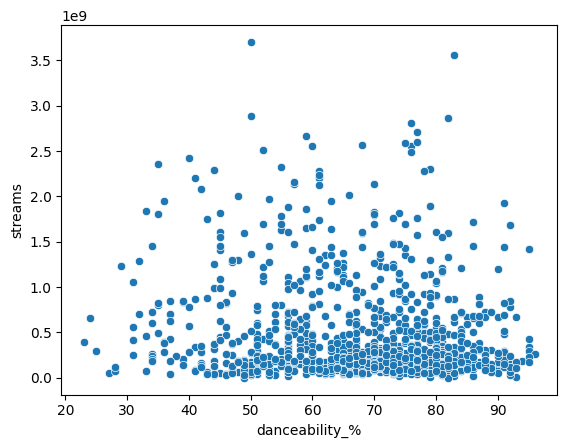

In [6]:
#Danceability is a measurement created by spotify.
#A quick viz of the raw data shows most hit songs are highly danceable.
sns.scatterplot(data = df, x = "danceability_%", y = "streams")

## Deriving Dollars From Streams

### Creating Artist Class with Payout Method

In [7]:
"""
I used my personal payout rate established by my distributor, DistroKid, and Spotify.
My band and I recieve $0.004 for every stream on spotify.

This class is for creating Artist objects with name and song values as well as a payout() method.

"""

'\nI used my personal payout rate established by my distributor, DistroKid, and Spotify.\nMy band and I recieve $0.004 for every stream on spotify.\n\nThis class is for creating Artist objects with name and song values as well as a payout() method.\n\n'

In [8]:


class Artist:

  def __init__(self, name, df):
    self.name = name
    self.df = df
    self.songs = df[df["artist(s)_name"] == name]

  def payout(self, PAYOUT_RATE = 0.004 ):

    total_cash = 0

#Since royalties are split between artists, I'm counting collaborations as partial streams.
#The "artist_count" column describes how many other artists are on the track.

    for idx, song in self.songs.iterrows():


      valid_streams = song["streams"] / song["artist_count"]

      song_payout = valid_streams * PAYOUT_RATE
      total_cash += song_payout

    return total_cash



##Winner(s)

In [9]:
"""
First I create a dictrionary with each artist's name and payout as a key:value pair.
Then I convert this to a df.
Finally, sorted_payouts is a version of this df where the highest values are at listed first.
"""

"\nFirst I create a dictrionary with each artist's name and payout as a key:value pair.\nThen I convert this to a df. \nFinally, sorted_payouts is a version of this df where the highest values are at listed first. \n"

In [10]:
artist_payouts = {}
artist_roster = df["artist(s)_name"]

for artist in artist_roster:
  try:
     artist_obj = Artist(artist, df)
     artist_payouts[artist] = artist_obj.payout()
  except:
    print(f"Could not process {artist}")

In [11]:
payouts_df = pd.DataFrame(list(artist_payouts.items()), columns= ["Artist", "Earnings"])
sorted_payouts = payouts_df.sort_values('Earnings', ascending=False)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'The Weeknd'),
  Text(1, 0, 'Taylor Swift'),
  Text(2, 0, 'Ed Sheeran'),
  Text(3, 0, 'Harry Styles'),
  Text(4, 0, 'Bad Bunny'),
  Text(5, 0, 'Olivia Rodrigo'),
  Text(6, 0, 'Eminem'),
  Text(7, 0, 'Bruno Mars')])

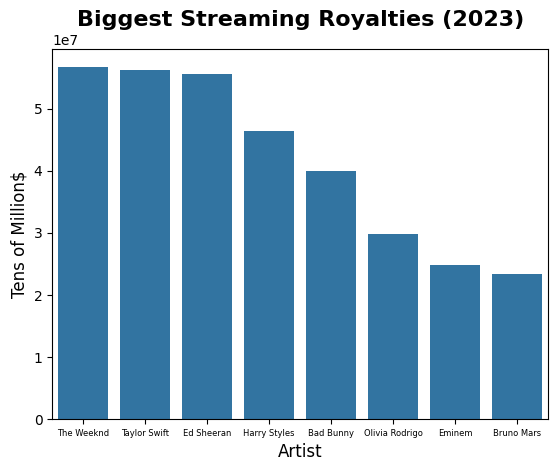

In [12]:
sns.barplot(data = sorted_payouts.head(8), x= "Artist", y= "Earnings")
plt.title('Biggest Streaming Royalties (2023)', fontsize=16, fontweight='bold')
plt.ylabel('Tens of Million$', fontsize=12)
plt.xlabel('Artist', fontsize=12)
plt.xticks(fontsize = 6)

In [13]:
"""
The Weekend wins with over $50,000,000 in streaming revenue. Bruno Mars takes 8th place with around $25,000,000.
Onyl the top 8 artists are shown for clarity.
"""

' \nThe Weekend wins with over $50,000,000 in streaming revenue. Bruno Mars takes 8th place with around $25,000,000. \nOnyl the top 8 artists are shown for clarity.\n'